In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm
from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *
import matplotlib.pyplot as plt
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
dic = {"path": sample_path,
       }

In [3]:
### SETTINGS ###

dataname = "path"
size = 2500
d = 2 #dummy dimension

project = "ffm-ipynb"
adata = process_fake_data(size, d, dic[dataname])
timepoints = sorted(adata.obs['timepoint'].unique().tolist())
tree = adata.uns['tree']

config = load_config()
OmegaConf.set_struct(config, False)
config.pc_dim = d
config.num_classes = adata.obs['cell_type'].nunique()

config.t0_index = 0
config.t1_index = 2
config.score_batch_size = 1024

In [4]:

config.metric = "cfm"
config.finsler.use = True
config.finsler.lamb = 5.0
config.dummy_kl_weight = 0.05

config.classifier.num_layers = 2
config.classifier.hidden_dim = 256
config.classifier.epsilon = 0.05

config.classifier_max_epochs = 1000
config.metric_max_epochs = 2
config.flow_max_epochs = 2

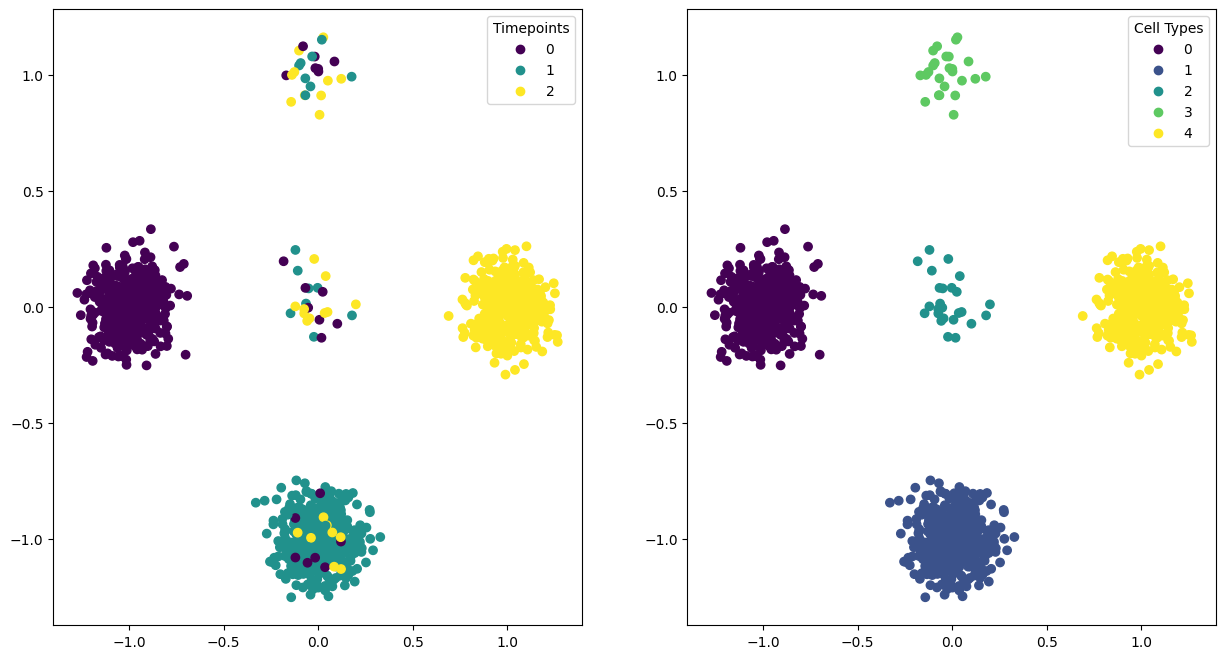

In [5]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, 2, figsize = (15, 8))
scatter0 = axs[0].scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs[0].legend(handles, labels, title="Timepoints")
scatter1 = axs[1].scatter(samples[:,0], samples[:, 1], c=adata.obs['cell_type_one_hot'].astype(int).tolist())
handles, labels = scatter1.legend_elements()
axs[1].legend(handles, labels, title="Cell Types")

plt.show()

In [6]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]
adata = adata[(adata.obs['timepoint'] >= t0) & (adata.obs['timepoint'] <= t1)]
adata_train = adata[adata.obs['timepoint'].isin([t0, t1])]
print(t0, t1)

0 2


In [7]:
singleton_dataloader = build_singleton_dataloader(config, adata_train)
paired_dataloader = build_paired_dataloader(config, adata_train)

In [8]:

classifier_model, metric_model, embed_model, flow_model = run_full_model(config=config,
                                                                         project=project,
                                                                         singleton_dataloader=singleton_dataloader,
                                                                         paired_dataloader=paired_dataloader,
                                                                         timepoints=timepoints,
                                                                         tree=tree)

{'pc_dim': 2, 'num_classes': 5, 'seed': 42, 'classifier_max_epochs': 1000, 'metric_max_epochs': 2, 'embed_max_epochs': 3000, 'flow_max_epochs': 2, 'gradient_clip_val': 0, 'warmup_steps': 0, 'loader_batch_size': 6, 'flow_batch_size': 512, 'score_batch_size': 1024, 'ema_decay': '1-1e-3', 'use_paga': False, 'lr': 0.001, 'dropout': 0.0, 'hidden_dim': 256, 'latent_dim': 100, 'num_layers': 3, 'num_freq': 32, 'rescale': 0.5, 'skip': False, 'normalize': True, 'balance_classes': False, 'force_cpu': False, 'detect_anomaly': False, 'use_wandb': True, 'dummy_prior': 0.05, 'dummy_kl_weight': 0.05, 'classifier': {'hidden_dim': 256, 'num_layers': 2, 'spectral_norm': False, 'epsilon': 0.05}, 'metric': 'cfm', 'sigma': 0.0, 'ot_in_embed': True, 'fast_ot': False, 'no_learning': False, 'time_per_batch': 4, 'random_velocities': False, 'method': 'exact', 'reg': -1, 'reg_m': -1, 'mfm': {'K': 150, 'kappa': 1.5, 'alpha': 1.0, 'epsilon': 0.1, 'use_euclidean_ot': False}, 'finsler': {'use': True, 'temp': 1.0, 'la

wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type           | Params | Mode 
----------------------------------------------------

epoch,▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇██
train_ce,█▆▆▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_kl,█▁▂▂▂▁▁▁▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_classifier,█▅▄▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
epoch,999
train_ce,0.03984
train_kl,2.16112
train_loss_classifier,0.1479
trainer/global_step,999


Running phase metric:.......


...

epoch,▁█
train_loss_metric,▁▁
trainer/global_step,▁█
epoch,1
train_loss_metric,0
trainer/global_step,1


Running phase embed:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 159 K  | train
1 | geo_net      | SinNet         | 151 K  | train
2 | metric_model | FinslerCFM     | 69.1 K | eval 
  | other params | n/a            | 50     | n/a  
--------------------------------------------------------
310 K     Trainable params
69.1 K    Non-trainable params
380 K     Total params
1.520     Total estimated

Restored best model from epoch 1528 with train_loss_geo_embed=3.447940


epoch,▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█
train_loss_embed,▆▃▅▅▃▇▄▄▃▄█▂▄▅▂▃▃▂▁▁▂▂▃▄▂▂▃▂▂▂▂▁▂▁▁▂▇▃▃▂
train_loss_geo,▂▇▃▂▂▂▂▂▃▂▂▂▃▂▂▂▁▁▂▂▁▁▂▃▃▃▂▂▂▂▂▂▁▁▂█▃▃▂▃
train_loss_geo_embed,▃▃▃▄▄▃▂▂█▂▂▃▂▅▂▂▃▂▂▂▂▁▃▂▇▃▃▃▇▃▃▃▄▃▂▃▂▂▂▃
trainer/global_step,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▇▇▇▇▇▇████
epoch,2999
train_loss_embed,0.2798
train_loss_geo,5.51859
train_loss_geo_embed,5.79839
trainer/global_step,2999


In [9]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [10]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]

w1_scores = []
for index in range(config.t0_index + 1, config.t1_index):
    print(index)
    t = timepoints[index]
    w1 = predict(embed_model, adata, t0, t, t1, num_traj=6000, library="pot")
    w1_scores.append(w1)
w1_scores = torch.tensor(w1_scores)
print(w1_scores)
print(torch.mean(w1_scores))

1


/home/azweig/projects/finfm/models/embed_models.py:135: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(j)


tensor([0.4278])
tensor(0.4278)


/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/ot/lp/_network_simplex.py:574: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  check_result(result_code)


In [11]:
# CFM: 0.9877
# Finlser +CFM: 0.3965

/tmp/ipykernel_1142552/743232393.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
/tmp/ipykernel_1142552/743232393.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.arange(y_min, y_max, h))


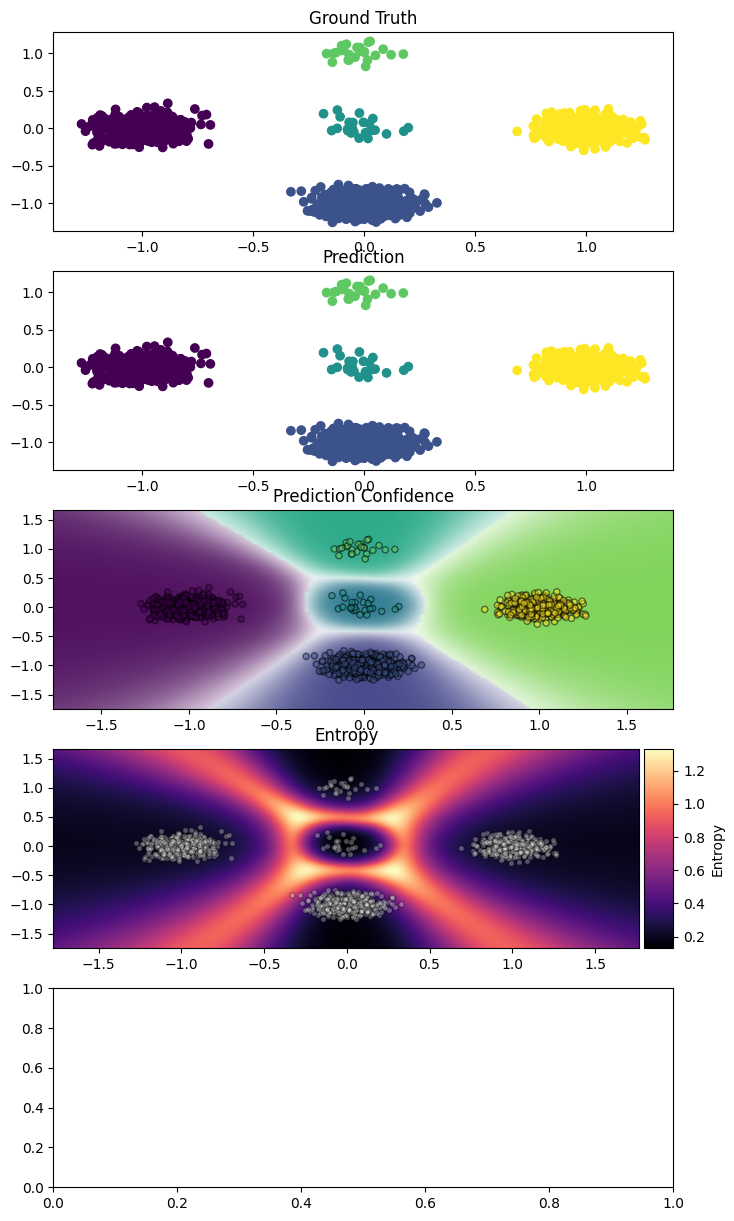

In [12]:
if config.finsler.use:

    X = torch.from_numpy(adata.obsm['X_pca']).float()
    y = torch.from_numpy(adata.obs['cell_type_one_hot'].astype(int).to_numpy()).long()
    y_pred = classifier_model(X, normalize=True).argmax(dim=1)

    fig, axs = plt.subplots(5, figsize = (8,15))
    axs[0].scatter(X[:,0], X[:, 1], c=y)
    axs[0].set_title("Ground Truth")
    axs[1].scatter(X[:,0], X[:, 1], c=y_pred)
    axs[1].set_title("Prediction")

    
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02  # Step size for the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.FloatTensor(grid_points)

    grid_tensor = F.pad(grid_tensor, pad=(0, d-2, 0, 0), mode='constant', value=0)

    with torch.no_grad():
        logits = classifier_model(grid_tensor, normalize=True)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    predictions = np.argmax(probs, axis=1)
    confidence = np.max(probs, axis=1)

    # Z = predictions.cpu().numpy().reshape(xx.shape)
    
    # axs[2].contourf(xx, yy, Z, alpha=0.3, cmap='viridis')    
    # scatter = axs[2].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)

    # plt.tight_layout()
    # plt.show()
    
    cmap = plt.get_cmap('viridis', probs.shape[1])
    grid_colors = cmap(predictions)[:, :3]
    rgba_image = np.zeros((grid_colors.shape[0], 4))
    rgba_image[:, :3] = grid_colors
    rgba_image[:, 3] = confidence**2  # Squaring for better visual contrast

    Z_conf = rgba_image.reshape(xx.shape[0], xx.shape[1], 4)
    
    axs[2].imshow(Z_conf, extent=(x_min, x_max, y_min, y_max), 
                  origin='lower', aspect='auto', interpolation='bilinear')
    axs[2].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=20, alpha=0.5)
    axs[2].set_title("Prediction Confidence")

    epsilon = 1e-10
    entropy = -np.sum(probs * np.log(probs + epsilon), axis=1)
    
    Z_entropy = entropy.reshape(xx.shape)

    im = axs[3].imshow(Z_entropy, extent=(x_min, x_max, y_min, y_max), 
                       origin='lower', aspect='auto', interpolation='bilinear', 
                       cmap='magma')
    
    # plt.colorbar(im, ax=axs[3], label='Entropy')
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(axs[3])
    cax = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax, label='Entropy')
    
    axs[3].scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=15, alpha=0.3)
    axs[3].set_title("Entropy")

    # f_x = metric_model.classifier_fn(grid_tensor)

    # A = metric_model.tree.to(metric_model.get_device())
    # M = A + A.T + torch.eye(f_x.shape[-1], device=f_x.device)

    # conformal = torch.sum(f_x * (f_x @ (1 - M)), dim=-1)
    # conformal = torch.sqrt(conformal)
    # Z = conformal.cpu().numpy().reshape(xx.shape)
    # contour = axs[4].contourf(xx, yy, Z, levels=100, cmap='inferno')
    # axs[4].scatter(X[:, 0], X[:, 1], s=2, alpha=0.005)
    # fig.colorbar(contour, ax=axs[4], label="metric tensor")
    # plt.show()


    

In [13]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from datasets.dataset import *

dataset = extract_paired_dataset(adata_train)
train_dataset = ShufflingDataset(dataset, 20)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

cpu


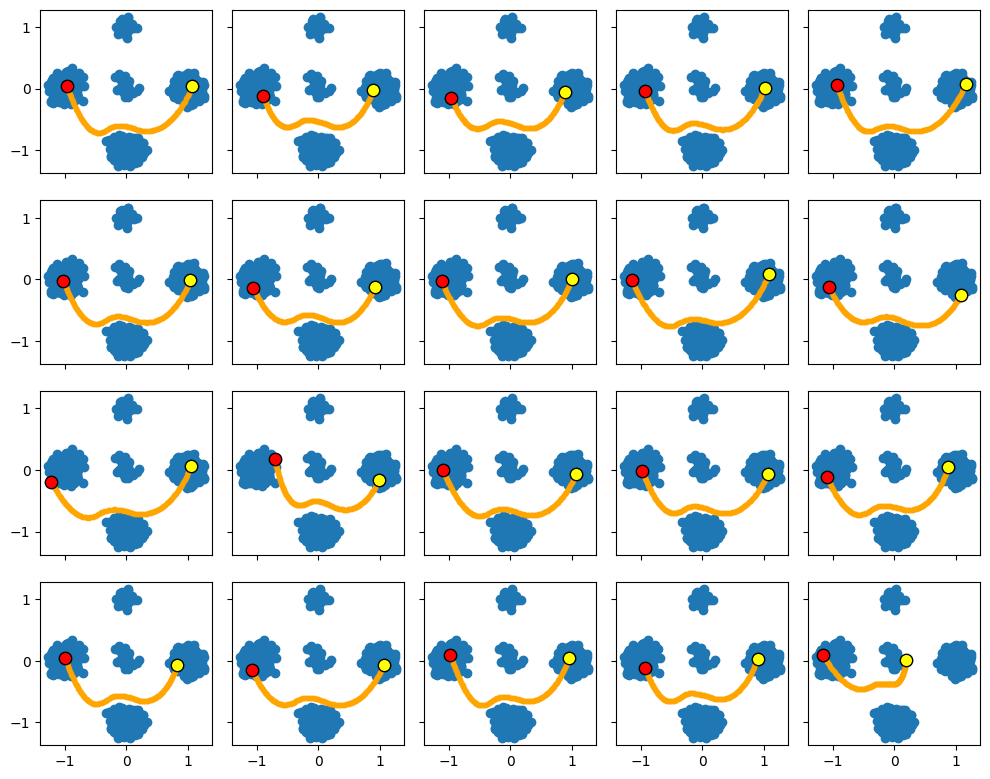

In [14]:
#GEO VALIDATION
for batch in train_dataloader:

    x0, x1, t0, t1 = batch
    print(x0.device)
    
    paths = embed_model.sample_geodesic_path(batch, num_points=200, ot_sample=False)

    break

fig, ax = plt.subplots(4, 5, figsize=(10, 8), sharex=True, sharey=True)

ax = ax.flatten()

for i in range(20):
    traj = paths[:,i]
    ax[i].scatter(samples[:,0], samples[:, 1])
    ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
    ax[i].scatter(traj[0, 0], traj[0, 1], s=80, marker="o", color="red", edgecolor="black", zorder=3)
    ax[i].scatter(traj[-1, 0], traj[-1, 1], s=80, marker="o", color="yellow", edgecolor="black", zorder=3)

    ax[i].set(adjustable='box', aspect='equal')

plt.tight_layout() # Optional: adjusts spacing so labels don't overlap
plt.show()

/home/azweig/projects/finfm/models/embed_models.py:135: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(j)


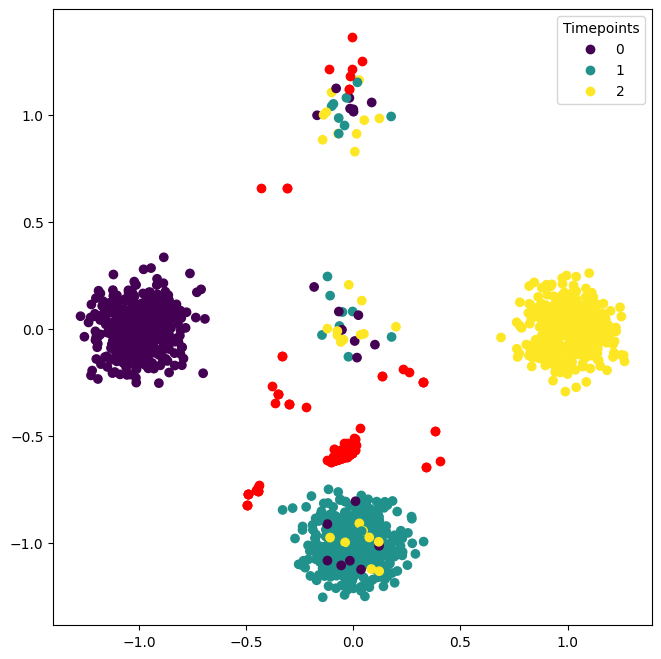

In [15]:
#GEO INTERPOLATION VALIDATION

t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]
t = (t0+t1) // 2

adata_prune = adata[adata.obs['timepoint'].isin([t0, t1])]
dataset = extract_paired_dataset(adata_prune)
train_dataset = ShufflingDataset(dataset, 512)
train_dataloader = DataLoader(train_dataset, batch_size = 1)

batch = next(iter(train_dataloader))
samples, weights = embed_model.sample_geodesic_time(batch, t, weighted = True)
weights = torch.softmax(weights, dim=0)
#TODO: weight?

true = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, figsize = (15, 8))
scatter0 = axs.scatter(true[:,0], true[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs.legend(handles, labels, title="Timepoints")
axs.scatter(samples[:,0], samples[:,1], c="red")
axs.set_aspect('equal')

plt.show()

torch.Size([200, 512, 2]) torch.Size([200, 512])
torch.Size([512])


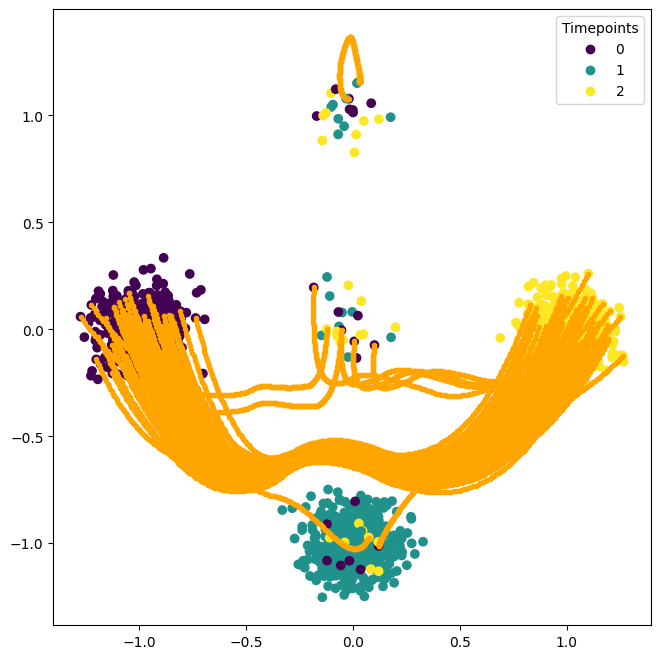

In [16]:
adata_prune = adata[adata.obs['timepoint'].isin([t0, t1])]
dataset = extract_paired_dataset(adata_prune)
train_dataset = ShufflingDataset(dataset, 512)
train_dataloader = DataLoader(train_dataset, batch_size = 1)


batch = next(iter(train_dataloader))
paths, weights = embed_model.sample_geodesic_path(batch, num_points=200, weighted=True)
print(paths.shape, weights.shape)
weights = torch.max(weights, dim = 0)[0]
weights = torch.softmax(weights, dim = 0)
min_val = torch.min(weights)
max_val = torch.max(weights)
weights = (weights - min_val) / (max_val - min_val)
print(weights.shape)
if config.method == "exact":
        weights = torch.ones_like(weights)

samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, axs = plt.subplots(1, figsize = (15, 8))
scatter0 = axs.scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
handles, labels = scatter0.legend_elements()
axs.legend(handles, labels, title="Timepoints")
for i in range(100):
        axs.plot(paths[:, i, 0], paths[:,i, 1], marker=".", linestyle="-", alpha=weights[i].item(), lw=1.5, color='orange')
axs.set_aspect('equal')

plt.show()

/tmp/ipykernel_1142552/1808568557.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits = classifier_model.classify(torch.tensor(paths_flat, device=device).float())


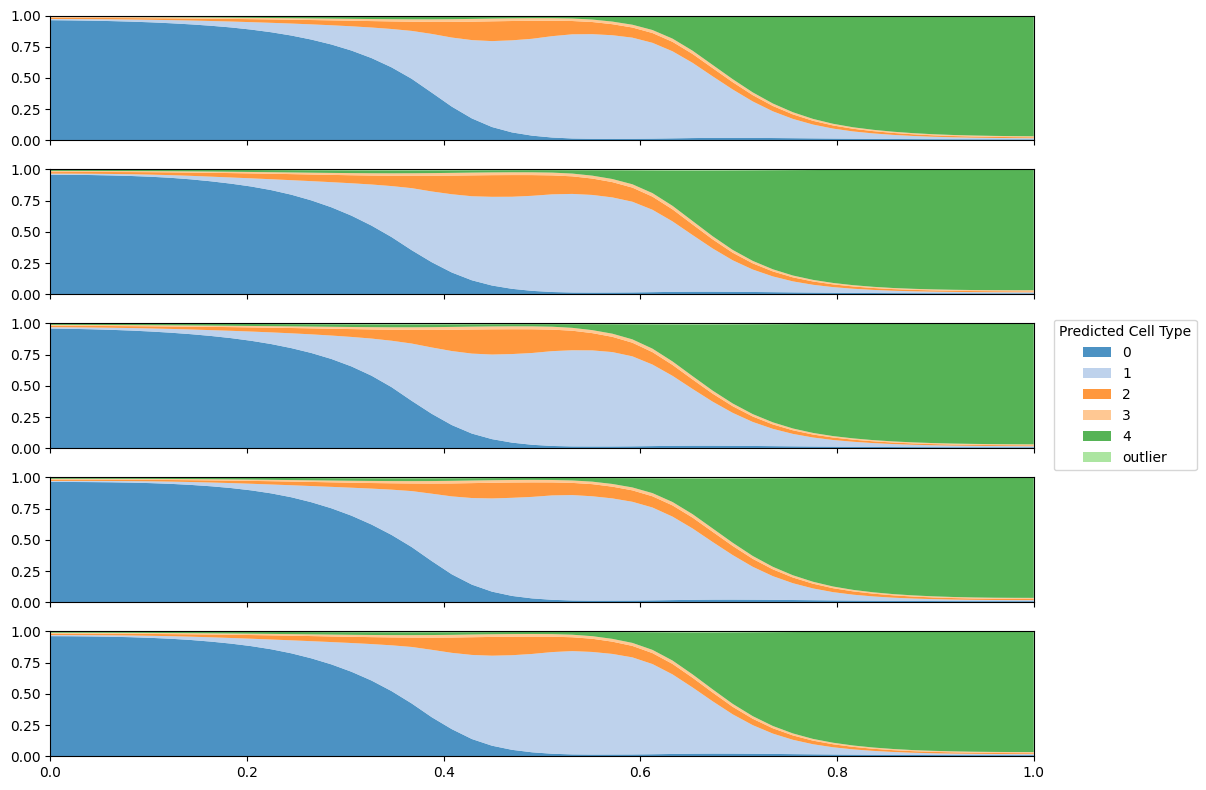

In [17]:
device = embed_model.device

batch = next(iter(paired_dataloader))
x0, x1, _, _ = embed_model._prepare_batch(batch)

paths = embed_model.sample_geodesic_path(batch, num_points=50)
paths_flat = paths.reshape(-1, paths.shape[-1])

time_axis = np.linspace(0, 1, 50)

with torch.no_grad():
    logits = classifier_model.classify(torch.tensor(paths_flat, device=device).float())
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    
probs = probs.reshape(paths.shape[0], paths.shape[1], -1)

cell_types = [str(i) for i in range(5)] + ["outlier"]

fig, axes = plt.subplots(5, figsize=(12, 8), sharex=True, sharey=True)

flat_axes = axes.flatten()

for i in range(len(flat_axes)):
    traj = probs[:,i]
    ax = flat_axes[i]
    ax.stackplot(time_axis, traj.T, labels=cell_types, alpha=0.8, colors=plt.cm.tab20.colors)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

handles, labels = flat_axes[0].get_legend_handles_labels()

fig.legend(
    handles, 
    labels, 
    loc='center right',       # Position on the right edge
    bbox_to_anchor=(1, 0.5),  # Anchor point relative to figure
    title="Predicted Cell Type"
)

plt.tight_layout(rect=[0, 0, 0.88, 1]) 
plt.show()